In [3]:
from pathlib import Path
import sys

import joblib
import json
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold


def find_project_root(start=None):
    """현재 실행 위치에서 Team-7 루트 폴더를 찾아 경로 오류를 줄입니다."""
    start = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start, *start.parents]

    for candidate in candidates:
        if (candidate / "data" / "data_team7.csv").exists():
            return candidate

    raise FileNotFoundError(
        "data/data_team7.csv를 찾지 못했습니다. "
        "노트북을 Team-7 리포지토리 안에서 실행하고 있는지 확인해주세요."
    )


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

from data.preprocessing_fe import get_hr_data_fe

RANDOM_STATE = 42
DATA_PATH = PROJECT_ROOT / "data" / "data_team7.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
FE_RESULTS_DIR = RESULTS_DIR / "lgbm_fe_experiments"
FE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"FE_RESULTS_DIR: {FE_RESULTS_DIR}")


def evaluate_binary_model(y_true, y_prob, threshold):
    """확률 예측값과 threshold를 받아 공통 성능 지표를 계산합니다."""
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Threshold": round(float(threshold), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
        "PR-AUC": round(average_precision_score(y_true, y_prob), 4),
        "LogLoss": round(log_loss(y_true, y_prob), 4),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "ConfusionMatrix": cm,
    }


def find_best_f1_threshold(y_true, y_prob):
    """Validation set에서 F1이 가장 커지는 threshold를 찾습니다."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    # precision_recall_curve의 thresholds는 precision/recall보다 길이가 1 작습니다.
    f1_scores = 2 * precisions[:-1] * recalls[:-1] / (
        precisions[:-1] + recalls[:-1] + 1e-10
    )

    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]


def normalize_binary_target(y):
    """타깃값이 Yes/No 문자열이어도 항상 0/1 정수 Series로 맞춥니다."""
    y = pd.Series(y).replace({"Yes": 1, "No": 0}).astype(int)
    return y


def calculate_scale_pos_weight(y_train):
    """LightGBM 클래스 불균형 가중치를 안전하게 계산합니다."""
    y_train = normalize_binary_target(y_train)
    negative_count = int((y_train == 0).sum())
    positive_count = int((y_train == 1).sum())

    print(f"target distribution: negative={negative_count}, positive={positive_count}")

    if positive_count == 0:
        raise ValueError(
            "y_train에 positive class(Attrition=1)가 없습니다. "
            "타깃 인코딩이나 데이터 분할 결과를 확인해주세요."
        )

    return negative_count / positive_count


def load_fe_data():
    """FE 전처리 데이터를 불러오고 feature name까지 함께 반환합니다."""
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = get_hr_data_fe(
        DATA_PATH,
        model_type="lgbm_tabnet",
        return_feature_names=True,
    )

    # preprocessing_fe.py에서 이미 변환하지만, 노트북 실행 순서/캐시 문제를 막기 위해 한 번 더 보정합니다.
    y_train = normalize_binary_target(y_train)
    y_valid = normalize_binary_target(y_valid)
    y_test = normalize_binary_target(y_test)

    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_valid_df = pd.DataFrame(X_valid, columns=feature_names)
    X_test_df = pd.DataFrame(X_test, columns=feature_names)

    return X_train_df, X_valid_df, X_test_df, y_train, y_valid, y_test, feature_names


def make_lgbm_base_model(y_train):
    """클래스 불균형 비율을 반영한 LightGBM 기본 모델을 생성합니다."""
    scale_pos_weight = calculate_scale_pos_weight(y_train)
    print(f"scale_pos_weight: {scale_pos_weight:.4f}")

    return lgb.LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight,
        n_estimators=100,
        min_child_samples=10,
        verbose=-1,
    )


def summarize_best_model(model, X_valid, X_test, y_valid, y_test, model_name, search_method, cv_best_score):
    """Validation에서 threshold를 정하고 Test 성능까지 같은 형식으로 정리합니다."""
    y_valid_prob = model.predict_proba(X_valid)[:, 1]
    best_threshold, best_valid_f1 = find_best_f1_threshold(y_valid, y_valid_prob)

    y_test_prob = model.predict_proba(X_test)[:, 1]
    valid_result = evaluate_binary_model(y_valid, y_valid_prob, best_threshold)
    test_result = evaluate_binary_model(y_test, y_test_prob, best_threshold)

    rows = []
    for dataset_name, result in [("Validation", valid_result), ("Test", test_result)]:
        rows.append({
            "Model": model_name,
            "Feature Set": "FE",
            "Search Method": search_method,
            "Dataset": dataset_name,
            "CV Best PR-AUC": round(float(cv_best_score), 4),
            **{k: v for k, v in result.items() if k != "ConfusionMatrix"},
        })

    summary_df = pd.DataFrame(rows)
    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Validation best F1: {best_valid_f1:.4f}")
    display(summary_df)

    print("[Validation Confusion Matrix]")
    print(valid_result["ConfusionMatrix"])
    print("[Test Confusion Matrix]")
    print(test_result["ConfusionMatrix"])

    return summary_df


PROJECT_ROOT: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7
DATA_PATH: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7\data\data_team7.csv
FE_RESULTS_DIR: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7\results\lgbm_fe_experiments


### 그리드서치

In [4]:
def run_lgbm_gridsearch_fe():
    """FE 데이터로 GridSearchCV 튜닝을 수행합니다."""
    print("1. FE 데이터 로드")
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = load_fe_data()

    base_model = make_lgbm_base_model(y_train)

    param_grid = {
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7],
        "num_leaves": [7, 15, 31],
        "reg_alpha": [0, 0.1, 1],
        "reg_lambda": [0, 0.1, 1],
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    print("2. GridSearchCV 실행: 기준 지표 = PR-AUC")
    grid_search_fe = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    grid_search_fe.fit(X_train, y_train)

    print("\n3. 최적 하이퍼파라미터")
    print(grid_search_fe.best_params_)
    print(f"CV Best PR-AUC: {grid_search_fe.best_score_:.4f}")

    tuning_results = pd.DataFrame(grid_search_fe.cv_results_)[[
        "rank_test_score", "mean_test_score", "std_test_score",
        "param_learning_rate", "param_max_depth", "param_num_leaves",
        "param_reg_alpha", "param_reg_lambda",
    ]].sort_values("rank_test_score")

    display(tuning_results.head(10))
    tuning_results.to_csv(FE_RESULTS_DIR / "lgbm_grid_fe_tuning_results.csv", index=False, encoding="utf-8-sig")

    grid_summary_fe = summarize_best_model(
        grid_search_fe.best_estimator_,
        X_valid,
        X_test,
        y_valid,
        y_test,
        model_name="LightGBM",
        search_method="GridSearchCV",
        cv_best_score=grid_search_fe.best_score_,
    )
    grid_summary_fe.to_csv(FE_RESULTS_DIR / "lgbm_grid_fe_summary.csv", index=False, encoding="utf-8-sig")

    return grid_search_fe.best_estimator_, grid_search_fe, grid_summary_fe, feature_names


grid_lgbm_fe, grid_search_fe, grid_summary_fe, feature_names_fe = run_lgbm_gridsearch_fe()


1. FE 데이터 로드
target distribution: negative=863, positive=166
scale_pos_weight: 5.1988
2. GridSearchCV 실행: 기준 지표 = PR-AUC
Fitting 3 folds for each of 243 candidates, totalling 729 fits

3. 최적 하이퍼파라미터
{'learning_rate': 0.1, 'max_depth': 5, 'num_leaves': 7, 'reg_alpha': 1, 'reg_lambda': 1}
CV Best PR-AUC: 0.6143


,rank_test_score,mean_test_score,std_test_score,param_learning_rate,param_max_depth,param_num_leaves,param_reg_alpha,param_reg_lambda
116,1,0.614297,0.011040,0.10,5,7,1.0,1.0
143,2,0.612085,0.012226,0.10,7,7,1.0,1.0
142,3,0.605704,0.018933,0.10,7,7,1.0,0.1
224,4,0.603160,0.021341,0.20,7,7,1.0,1.0
197,5,0.602832,0.017604,0.20,5,7,1.0,1.0
219,6,0.602810,0.025065,0.20,7,7,0.1,0.0
62,7,0.601881,0.012495,0.05,7,7,1.0,1.0
115,8,0.601372,0.013036,0.10,5,7,1.0,0.1
141,9,0.601103,0.013982,0.10,7,7,1.0,0.0
196,10,0.599780,0.020288,0.20,5,7,1.0,0.1


Best threshold: 0.4425
Validation best F1: 0.4737


,Model,Feature Set,Search Method,Dataset,CV Best PR-AUC,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,LogLoss,TN,FP,FN,TP
0,LightGBM,FE,GridSearchCV,Validation,0.6143,0.4425,0.4390,0.5143,0.4737,0.7597,0.3806,0.4239,162,23,17,18
1,LightGBM,FE,GridSearchCV,Test,0.6143,0.4425,0.3617,0.4722,0.4096,0.7610,0.5014,0.4261,155,30,19,17


[Validation Confusion Matrix]
[[162  23]
 [ 17  18]]
[Test Confusion Matrix]
[[155  30]
 [ 19  17]]


### 랜덤서치

In [5]:
def run_lgbm_randomsearch_fe():
    """FE 데이터로 RandomizedSearchCV 튜닝을 수행합니다."""
    print("1. FE 데이터 로드")
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = load_fe_data()

    base_model = make_lgbm_base_model(y_train)

    param_distributions = {
        "learning_rate": [0.005, 0.01, 0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7, 9, -1],
        "num_leaves": [7, 15, 31, 63, 127],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "reg_alpha": [0, 0.01, 0.1, 1, 5],
        "reg_lambda": [0, 0.01, 0.1, 1, 5],
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    print("2. RandomizedSearchCV 실행: 기준 지표 = PR-AUC")
    random_search_fe = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=50,
        scoring="average_precision",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    random_search_fe.fit(X_train, y_train)

    print("\n3. 최적 하이퍼파라미터")
    print(random_search_fe.best_params_)
    print(f"CV Best PR-AUC: {random_search_fe.best_score_:.4f}")

    tuning_results = pd.DataFrame(random_search_fe.cv_results_)[[
        "rank_test_score", "mean_test_score", "std_test_score",
        "param_learning_rate", "param_max_depth", "param_num_leaves",
        "param_subsample", "param_colsample_bytree",
        "param_reg_alpha", "param_reg_lambda",
    ]].sort_values("rank_test_score")

    display(tuning_results.head(10))
    tuning_results.to_csv(FE_RESULTS_DIR / "lgbm_random_fe_tuning_results.csv", index=False, encoding="utf-8-sig")

    random_summary_fe = summarize_best_model(
        random_search_fe.best_estimator_,
        X_valid,
        X_test,
        y_valid,
        y_test,
        model_name="LightGBM",
        search_method="RandomizedSearchCV",
        cv_best_score=random_search_fe.best_score_,
    )
    random_summary_fe.to_csv(FE_RESULTS_DIR / "lgbm_random_fe_summary.csv", index=False, encoding="utf-8-sig")

    return random_search_fe.best_estimator_, random_search_fe, random_summary_fe, feature_names


best_lgbm_fe, lgbm_search_fe, lgbm_summary_fe, feature_names_fe = run_lgbm_randomsearch_fe()


1. FE 데이터 로드
target distribution: negative=863, positive=166
scale_pos_weight: 5.1988
2. RandomizedSearchCV 실행: 기준 지표 = PR-AUC
Fitting 3 folds for each of 50 candidates, totalling 150 fits

3. 최적 하이퍼파라미터
{'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0, 'num_leaves': 7, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
CV Best PR-AUC: 0.6107


,rank_test_score,mean_test_score,std_test_score,param_learning_rate,param_max_depth,param_num_leaves,param_subsample,param_colsample_bytree,param_reg_alpha,param_reg_lambda
48,1,0.610681,0.013254,0.20,7,7,0.7,0.7,0.00,5.00
43,2,0.596618,0.019226,0.10,7,31,0.7,0.7,5.00,1.00
49,3,0.596381,0.020799,0.20,7,63,0.8,0.8,5.00,5.00
41,4,0.593145,0.003596,0.10,9,31,0.8,0.8,1.00,5.00
30,5,0.589175,0.009374,0.05,9,15,0.9,0.8,0.00,5.00
9,6,0.588700,0.016021,0.10,-1,15,1.0,1.0,5.00,0.10
42,7,0.587789,0.020936,0.20,5,15,1.0,0.7,0.01,0.01
34,8,0.587564,0.009972,0.05,9,7,1.0,0.9,0.10,0.10
22,9,0.586885,0.013276,0.05,7,63,0.7,0.7,5.00,5.00
4,10,0.586856,0.013051,0.20,7,31,0.7,0.7,5.00,0.01


Best threshold: 0.2083
Validation best F1: 0.5000


,Model,Feature Set,Search Method,Dataset,CV Best PR-AUC,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,LogLoss,TN,FP,FN,TP
0,LightGBM,FE,RandomizedSearchCV,Validation,0.6107,0.2083,0.3846,0.7143,0.5000,0.7581,0.4260,0.4071,145,40,10,25
1,LightGBM,FE,RandomizedSearchCV,Test,0.6107,0.2083,0.3375,0.7500,0.4655,0.7779,0.5486,0.3998,132,53,9,27


[Validation Confusion Matrix]
[[145  40]
 [ 10  25]]
[Test Confusion Matrix]
[[132  53]
 [  9  27]]


### optuna

In [6]:
def run_lgbm_optuna_fe(n_trials=50):
    """FE 데이터로 Optuna 튜닝을 수행합니다."""
    print("1. FE 데이터 로드")
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = load_fe_data()

    scale_pos_weight = calculate_scale_pos_weight(y_train)
    print(f"scale_pos_weight: {scale_pos_weight:.4f}")

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        params = {
            "objective": "binary",
            "random_state": RANDOM_STATE,
            "scale_pos_weight": scale_pos_weight,
            "n_estimators": 100,
            "min_child_samples": 10,
            "verbose": -1,
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 9),
            "num_leaves": trial.suggest_int("num_leaves", 7, 127),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        }

        pr_auc_scores = []
        for train_idx, val_idx in cv.split(X_train, y_train):
            X_tr = X_train.iloc[train_idx]
            X_va = X_train.iloc[val_idx]
            y_tr = y_train.iloc[train_idx]
            y_va = y_train.iloc[val_idx]

            model = lgb.LGBMClassifier(**params)
            model.fit(X_tr, y_tr)
            y_va_prob = model.predict_proba(X_va)[:, 1]
            pr_auc_scores.append(average_precision_score(y_va, y_va_prob))

        return np.mean(pr_auc_scores)

    print("2. Optuna 실행: 기준 지표 = PR-AUC")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    optuna_study_fe = optuna.create_study(direction="maximize", study_name="LGBM_FE_Optuna")
    optuna_study_fe.optimize(objective, n_trials=n_trials)

    print("\n3. 최적 하이퍼파라미터")
    print(optuna_study_fe.best_params)
    print(f"CV Best PR-AUC: {optuna_study_fe.best_value:.4f}")

    best_params = {
        **optuna_study_fe.best_params,
        "objective": "binary",
        "random_state": RANDOM_STATE,
        "scale_pos_weight": scale_pos_weight,
        "n_estimators": 100,
        "min_child_samples": 10,
        "verbose": -1,
    }
    optuna_lgbm_fe = lgb.LGBMClassifier(**best_params)
    optuna_lgbm_fe.fit(X_train, y_train)

    optuna_summary_fe = summarize_best_model(
        optuna_lgbm_fe,
        X_valid,
        X_test,
        y_valid,
        y_test,
        model_name="LightGBM",
        search_method="Optuna",
        cv_best_score=optuna_study_fe.best_value,
    )
    optuna_summary_fe.to_csv(FE_RESULTS_DIR / "lgbm_optuna_fe_summary.csv", index=False, encoding="utf-8-sig")

    trials_df = optuna_study_fe.trials_dataframe()
    trials_df.to_csv(FE_RESULTS_DIR / "lgbm_optuna_fe_tuning_results.csv", index=False, encoding="utf-8-sig")

    return optuna_lgbm_fe, optuna_study_fe, optuna_summary_fe, feature_names


optuna_lgbm_fe, optuna_study_fe, optuna_summary_fe, feature_names_fe = run_lgbm_optuna_fe(n_trials=50)


1. FE 데이터 로드
target distribution: negative=863, positive=166
scale_pos_weight: 5.1988
2. Optuna 실행: 기준 지표 = PR-AUC

3. 최적 하이퍼파라미터
{'learning_rate': 0.07592114436153927, 'max_depth': 9, 'num_leaves': 7, 'subsample': 0.8130964536004787, 'colsample_bytree': 0.9624383071630394, 'reg_alpha': 4.714421143721598, 'reg_lambda': 4.06471886908142}
CV Best PR-AUC: 0.6110
Best threshold: 0.4496
Validation best F1: 0.4944


,Model,Feature Set,Search Method,Dataset,CV Best PR-AUC,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,LogLoss,TN,FP,FN,TP
0,LightGBM,FE,Optuna,Validation,0.611,0.4496,0.4074,0.6286,0.4944,0.7470,0.3679,0.4605,153,32,13,22
1,LightGBM,FE,Optuna,Test,0.611,0.4496,0.3051,0.5000,0.3789,0.7538,0.4632,0.4638,144,41,18,18


[Validation Confusion Matrix]
[[153  32]
 [ 13  22]]
[Test Confusion Matrix]
[[144  41]
 [ 18  18]]


### LGBM 최종 학습 실험 및 시각화

최적 파라미터를 모아 같은 기준으로 모델을 학습. 
Validation set에서 F1이 최대가 되는 threshold를 선택하고, Test set에서 최종 성능과 시각화 결과를 저장



===== grid_search_fe 최종 학습 시작 =====


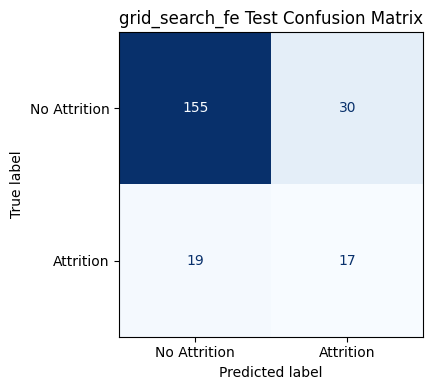

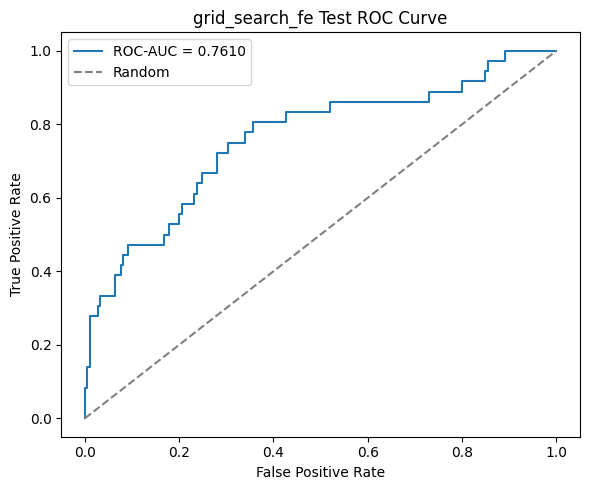

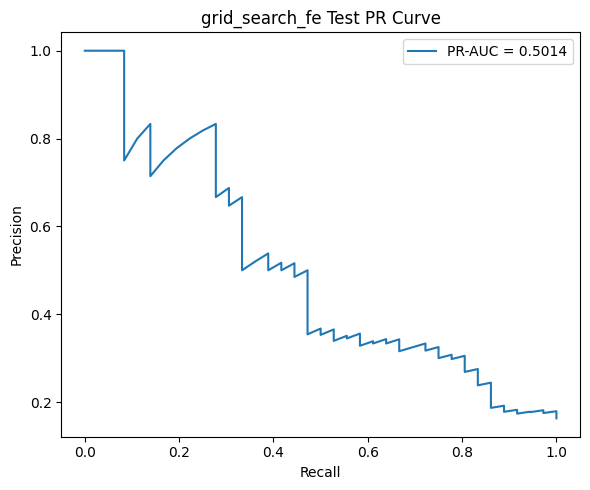

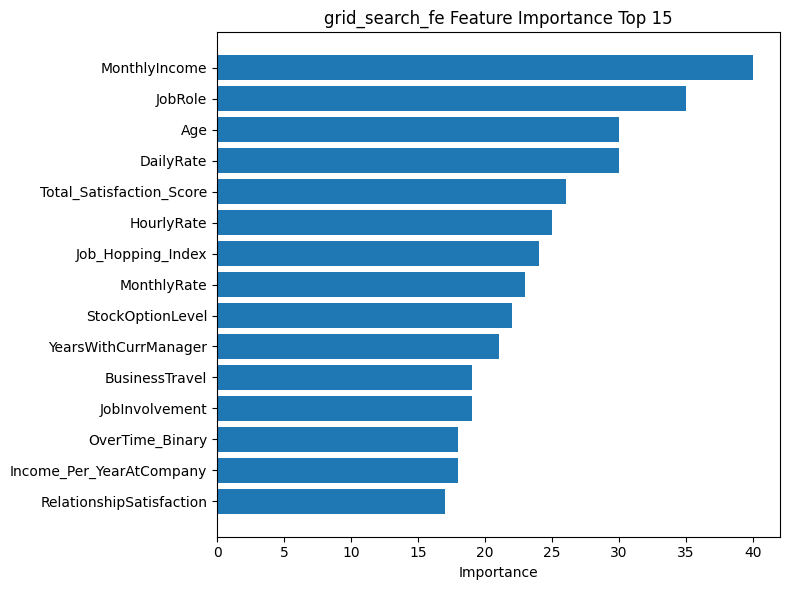

Best threshold: 0.4425
Validation F1: 0.4737
Test F1: 0.4096
Test PR-AUC: 0.5014
Top 5 features:


,Feature,Importance
9,MonthlyIncome,40
41,JobRole,35
1,DailyRate,30
0,Age,30
34,Total_Satisfaction_Score,26



===== random_search_fe 최종 학습 시작 =====


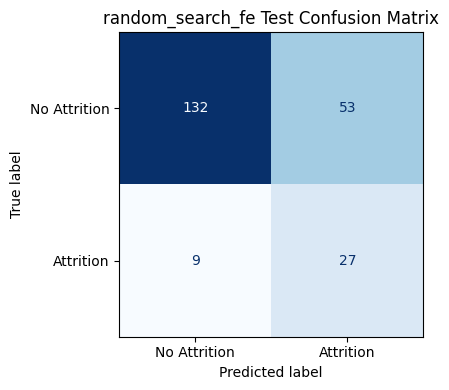

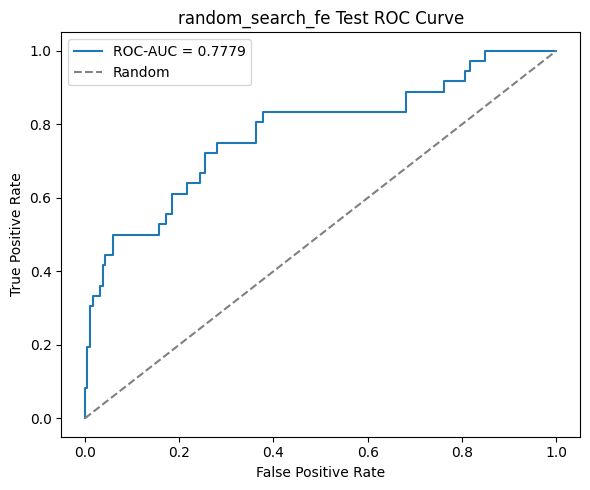

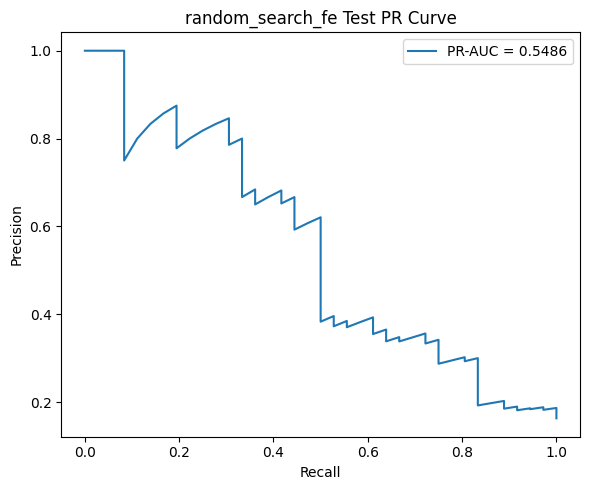

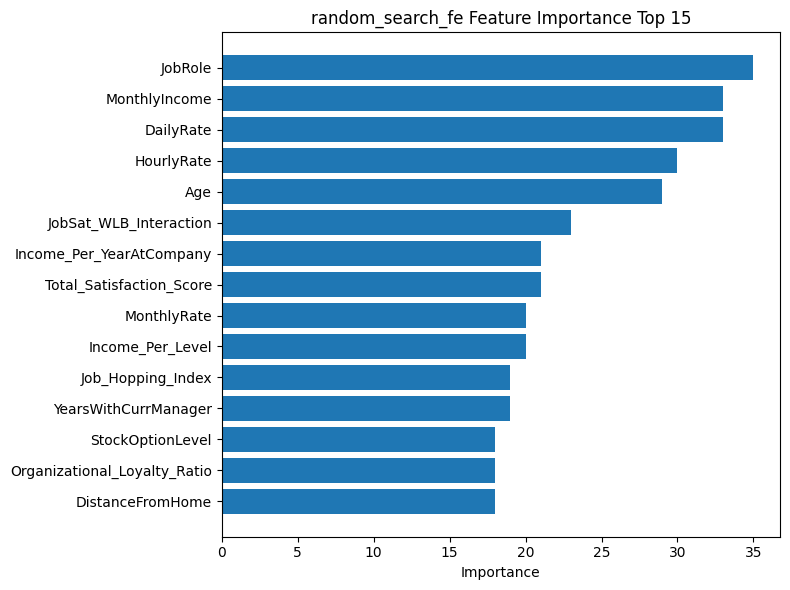

Best threshold: 0.2083
Validation F1: 0.5000
Test F1: 0.4655
Test PR-AUC: 0.5486
Top 5 features:


,Feature,Importance
41,JobRole,35
1,DailyRate,33
9,MonthlyIncome,33
5,HourlyRate,30
0,Age,29



===== optuna_fe 최종 학습 시작 =====


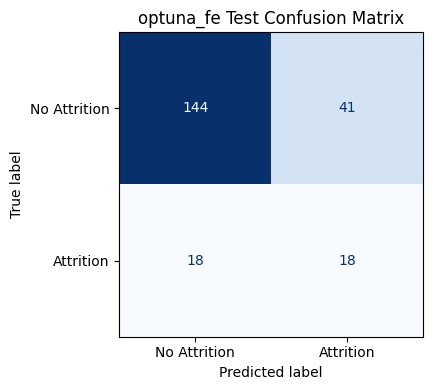

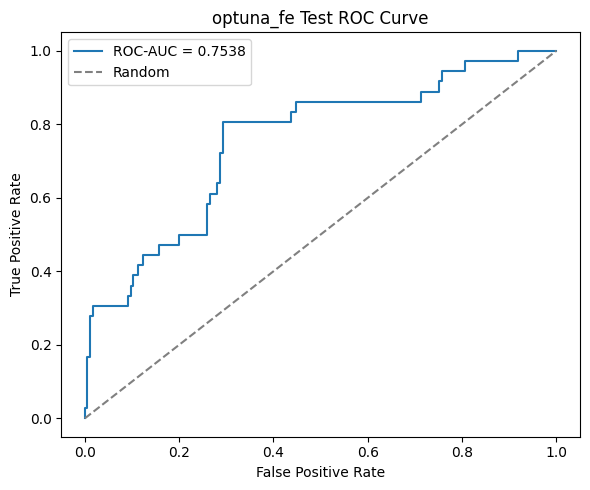

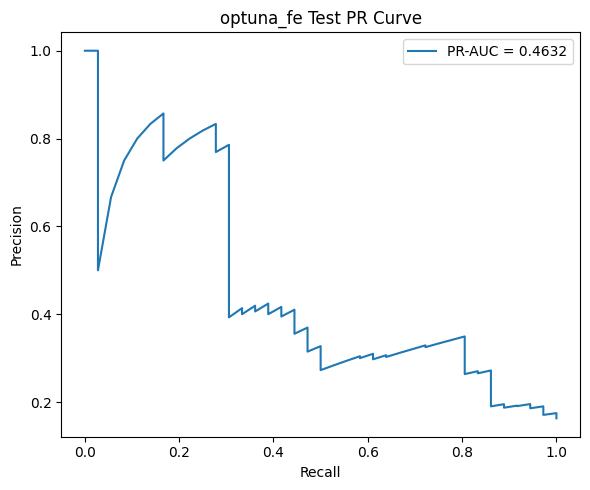

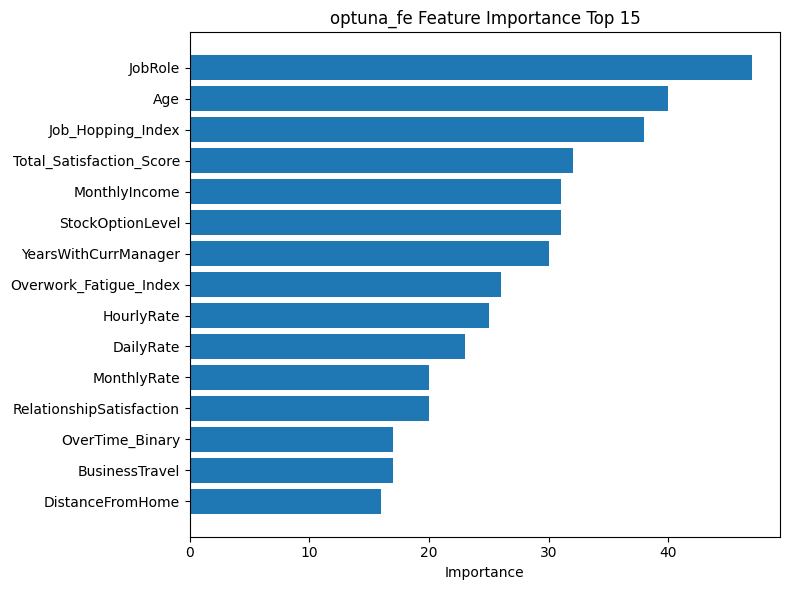

Best threshold: 0.4496
Validation F1: 0.4944
Test F1: 0.3789
Test PR-AUC: 0.4632
Top 5 features:


,Feature,Importance
41,JobRole,47
0,Age,40
35,Job_Hopping_Index,38
34,Total_Satisfaction_Score,32
15,StockOptionLevel,31



===== LGBM FE 최종 실험 요약 =====


,Model,Feature Set,Attempt,Search Method,Dataset,CV Best PR-AUC,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,LogLoss,TN,FP,FN,TP
0,LightGBM,FE,grid_search_fe,GridSearchCV,Validation,0.6143,0.4425,0.4390,0.5143,0.4737,0.7597,0.3806,0.4239,162,23,17,18
1,LightGBM,FE,grid_search_fe,GridSearchCV,Test,0.6143,0.4425,0.3617,0.4722,0.4096,0.7610,0.5014,0.4261,155,30,19,17
2,LightGBM,FE,random_search_fe,RandomizedSearchCV,Validation,0.6107,0.2083,0.3846,0.7143,0.5000,0.7581,0.4260,0.4071,145,40,10,25
3,LightGBM,FE,random_search_fe,RandomizedSearchCV,Test,0.6107,0.2083,0.3375,0.7500,0.4655,0.7779,0.5486,0.3998,132,53,9,27
4,LightGBM,FE,optuna_fe,Optuna,Validation,0.6110,0.4496,0.4074,0.6286,0.4944,0.7470,0.3679,0.4605,153,32,13,22
5,LightGBM,FE,optuna_fe,Optuna,Test,0.6110,0.4496,0.3051,0.5000,0.3789,0.7538,0.4632,0.4638,144,41,18,18



결과 저장 위치: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7\results\lgbm_fe_experiments


In [7]:
def save_confusion_matrix_plot(y_true, y_prob, threshold, save_path, title):
    """선택된 threshold 기준의 confusion matrix를 이미지로 저장합니다."""
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Attrition", "Attrition"])
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def save_roc_curve_plot(y_true, y_prob, save_path, title):
    """ROC curve를 그리고 ROC-AUC 값을 함께 표시합니다."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def save_pr_curve_plot(y_true, y_prob, save_path, title):
    """PR curve를 그리고 PR-AUC 값을 함께 표시합니다."""
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def save_feature_importance_plot(model, feature_names, save_csv_path, save_png_path, title):
    """LightGBM feature importance를 CSV와 Top 15 막대그래프로 저장합니다."""
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_,
    }).sort_values("Importance", ascending=False)

    importance_df.to_csv(save_csv_path, index=False, encoding="utf-8-sig")

    top_df = importance_df.head(15).sort_values("Importance")
    plt.figure(figsize=(8, 6))
    plt.barh(top_df["Feature"], top_df["Importance"])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_png_path, dpi=150)
    plt.show()
    plt.close()

    return importance_df


def build_fe_attempts_from_tuning_results():
    """앞선 FE 튜닝 결과 객체에서 각 방식의 최적 파라미터를 모읍니다."""
    attempts = []

    if "grid_search_fe" in globals():
        attempts.append({
            "Attempt": "grid_search_fe",
            "Search Method": "GridSearchCV",
            "CV Best PR-AUC": grid_search_fe.best_score_,
            "Params": grid_search_fe.best_params_,
        })

    if "lgbm_search_fe" in globals():
        attempts.append({
            "Attempt": "random_search_fe",
            "Search Method": "RandomizedSearchCV",
            "CV Best PR-AUC": lgbm_search_fe.best_score_,
            "Params": lgbm_search_fe.best_params_,
        })

    if "optuna_study_fe" in globals():
        attempts.append({
            "Attempt": "optuna_fe",
            "Search Method": "Optuna",
            "CV Best PR-AUC": optuna_study_fe.best_value,
            "Params": optuna_study_fe.best_params,
        })

    if not attempts:
        raise RuntimeError("FE 튜닝 결과 객체를 찾지 못했습니다. 위쪽 튜닝 셀을 먼저 실행해주세요.")

    return attempts


def run_final_lgbm_fe_experiments():
    """FE 튜닝 방식별 최적 파라미터로 최종 모델과 시각화를 저장합니다."""
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = load_fe_data()
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    attempts = build_fe_attempts_from_tuning_results()

    all_results = []

    for attempt in attempts:
        attempt_name = attempt["Attempt"]
        attempt_dir = FE_RESULTS_DIR / attempt_name
        attempt_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n===== {attempt_name} 최종 학습 시작 =====")

        params = {
            "objective": "binary",
            "random_state": RANDOM_STATE,
            "scale_pos_weight": scale_pos_weight,
            "n_estimators": 100,
            "min_child_samples": 10,
            "verbose": -1,
            **attempt["Params"],
        }

        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train)

        y_valid_prob = model.predict_proba(X_valid)[:, 1]
        best_threshold, best_valid_f1 = find_best_f1_threshold(y_valid, y_valid_prob)
        y_test_prob = model.predict_proba(X_test)[:, 1]

        valid_result = evaluate_binary_model(y_valid, y_valid_prob, best_threshold)
        test_result = evaluate_binary_model(y_test, y_test_prob, best_threshold)

        for dataset_name, result in [("Validation", valid_result), ("Test", test_result)]:
            all_results.append({
                "Model": "LightGBM",
                "Feature Set": "FE",
                "Attempt": attempt_name,
                "Search Method": attempt["Search Method"],
                "Dataset": dataset_name,
                "CV Best PR-AUC": round(float(attempt["CV Best PR-AUC"]), 4),
                **{k: v for k, v in result.items() if k != "ConfusionMatrix"},
            })

        with open(attempt_dir / "params.json", "w", encoding="utf-8") as f:
            json.dump(params, f, indent=4, ensure_ascii=False)
        joblib.dump(model, attempt_dir / "model.joblib")

        save_confusion_matrix_plot(
            y_test,
            y_test_prob,
            best_threshold,
            attempt_dir / "test_confusion_matrix.png",
            f"{attempt_name} Test Confusion Matrix",
        )
        save_roc_curve_plot(y_test, y_test_prob, attempt_dir / "test_roc_curve.png", f"{attempt_name} Test ROC Curve")
        save_pr_curve_plot(y_test, y_test_prob, attempt_dir / "test_pr_curve.png", f"{attempt_name} Test PR Curve")

        importance_df = save_feature_importance_plot(
            model,
            feature_names,
            attempt_dir / "feature_importance.csv",
            attempt_dir / "feature_importance_top15.png",
            f"{attempt_name} Feature Importance Top 15",
        )

        print(f"Best threshold: {best_threshold:.4f}")
        print(f"Validation F1: {valid_result['F1']:.4f}")
        print(f"Test F1: {test_result['F1']:.4f}")
        print(f"Test PR-AUC: {test_result['PR-AUC']:.4f}")
        print("Top 5 features:")
        display(importance_df.head(5))

    final_summary_fe = pd.DataFrame(all_results)
    final_summary_fe.to_csv(FE_RESULTS_DIR / "lgbm_fe_final_experiment_summary.csv", index=False, encoding="utf-8-sig")

    print("\n===== LGBM FE 최종 실험 요약 =====")
    display(final_summary_fe)
    print(f"\n결과 저장 위치: {FE_RESULTS_DIR}")

    return final_summary_fe


lgbm_fe_final_summary = run_final_lgbm_fe_experiments()
